In [68]:

import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
print(torch.__version__)

2.9.0+cu126


IMAGE LOADING

In [69]:
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch
import torchvision.transforms as transforms

In [70]:

ROOT = Path("Dataset/bottle")

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

In [71]:
class BottleTrainDataset(Dataset):

    def __init__(self, root, transform=None):
        self.image_paths = list(
            (root / "train" / "good").glob("*.png")
        )
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

In [72]:
train_dataset = BottleTrainDataset(
    ROOT,
    transform=transform
)

In [73]:

print("Number of training images:", len(train_dataset))
print("Image shape:", train_dataset[0].shape)
print ("Image tensor:", train_dataset[0])

Number of training images: 209
Image shape: torch.Size([3, 256, 256])
Image tensor: tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]])


In [74]:
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [75]:
images = next(iter(train_loader))
print(images.shape)

torch.Size([4, 3, 256, 256])


In [76]:
len(train_loader)

53

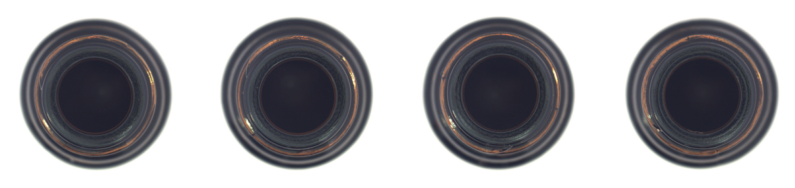

In [77]:
import matplotlib.pyplot as plt
images = next(iter(train_loader))
plt.figure(figsize=(10, 5))
for i in range(4):

    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.axis("off")

plt.show()

In [78]:
class BottleTestDataset(Dataset):
    def __init__(self, root, transform=None):
        self.image_paths = []
        self.labels = []

        test_path = root / "test"
        for defect_folder in test_path.iterdir():
            if not defect_folder.is_dir():
                continue
            if defect_folder.name == "good":
                label = 0
            else:
                label = 1

            for image_path in defect_folder.glob("*.png"):
                self.image_paths.append(image_path)
                self.labels.append(label)
                print(f"Image path: {image_path}, Label: {label}")
        self.transform = transform
        print(transform)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        image = Image.open(image_path).convert("RGB")
        label = self.labels[index]
        if self.transform:
            image = self.transform(image)

        return image, label

In [79]:
test_dataset = BottleTestDataset(
    ROOT,
    transform=transform
)

print("Number of test images:", len(test_dataset))

Image path: Dataset\bottle\test\broken_large\000.png, Label: 1
Image path: Dataset\bottle\test\broken_large\001.png, Label: 1
Image path: Dataset\bottle\test\broken_large\002.png, Label: 1
Image path: Dataset\bottle\test\broken_large\003.png, Label: 1
Image path: Dataset\bottle\test\broken_large\004.png, Label: 1
Image path: Dataset\bottle\test\broken_large\005.png, Label: 1
Image path: Dataset\bottle\test\broken_large\006.png, Label: 1
Image path: Dataset\bottle\test\broken_large\007.png, Label: 1
Image path: Dataset\bottle\test\broken_large\008.png, Label: 1
Image path: Dataset\bottle\test\broken_large\009.png, Label: 1
Image path: Dataset\bottle\test\broken_large\010.png, Label: 1
Image path: Dataset\bottle\test\broken_large\011.png, Label: 1
Image path: Dataset\bottle\test\broken_large\012.png, Label: 1
Image path: Dataset\bottle\test\broken_large\013.png, Label: 1
Image path: Dataset\bottle\test\broken_large\014.png, Label: 1
Image path: Dataset\bottle\test\broken_large\015.png, L

In [80]:
BATCH_SIZE = 4

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [81]:
from collections import Counter
print(Counter(test_dataset.labels))

Counter({1: 63, 0: 20})


In [82]:
print(train_dataset[0])
print(len(train_dataset))
print(train_dataset[0].shape)

tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]])
209
torch.Size([3, 256, 256])


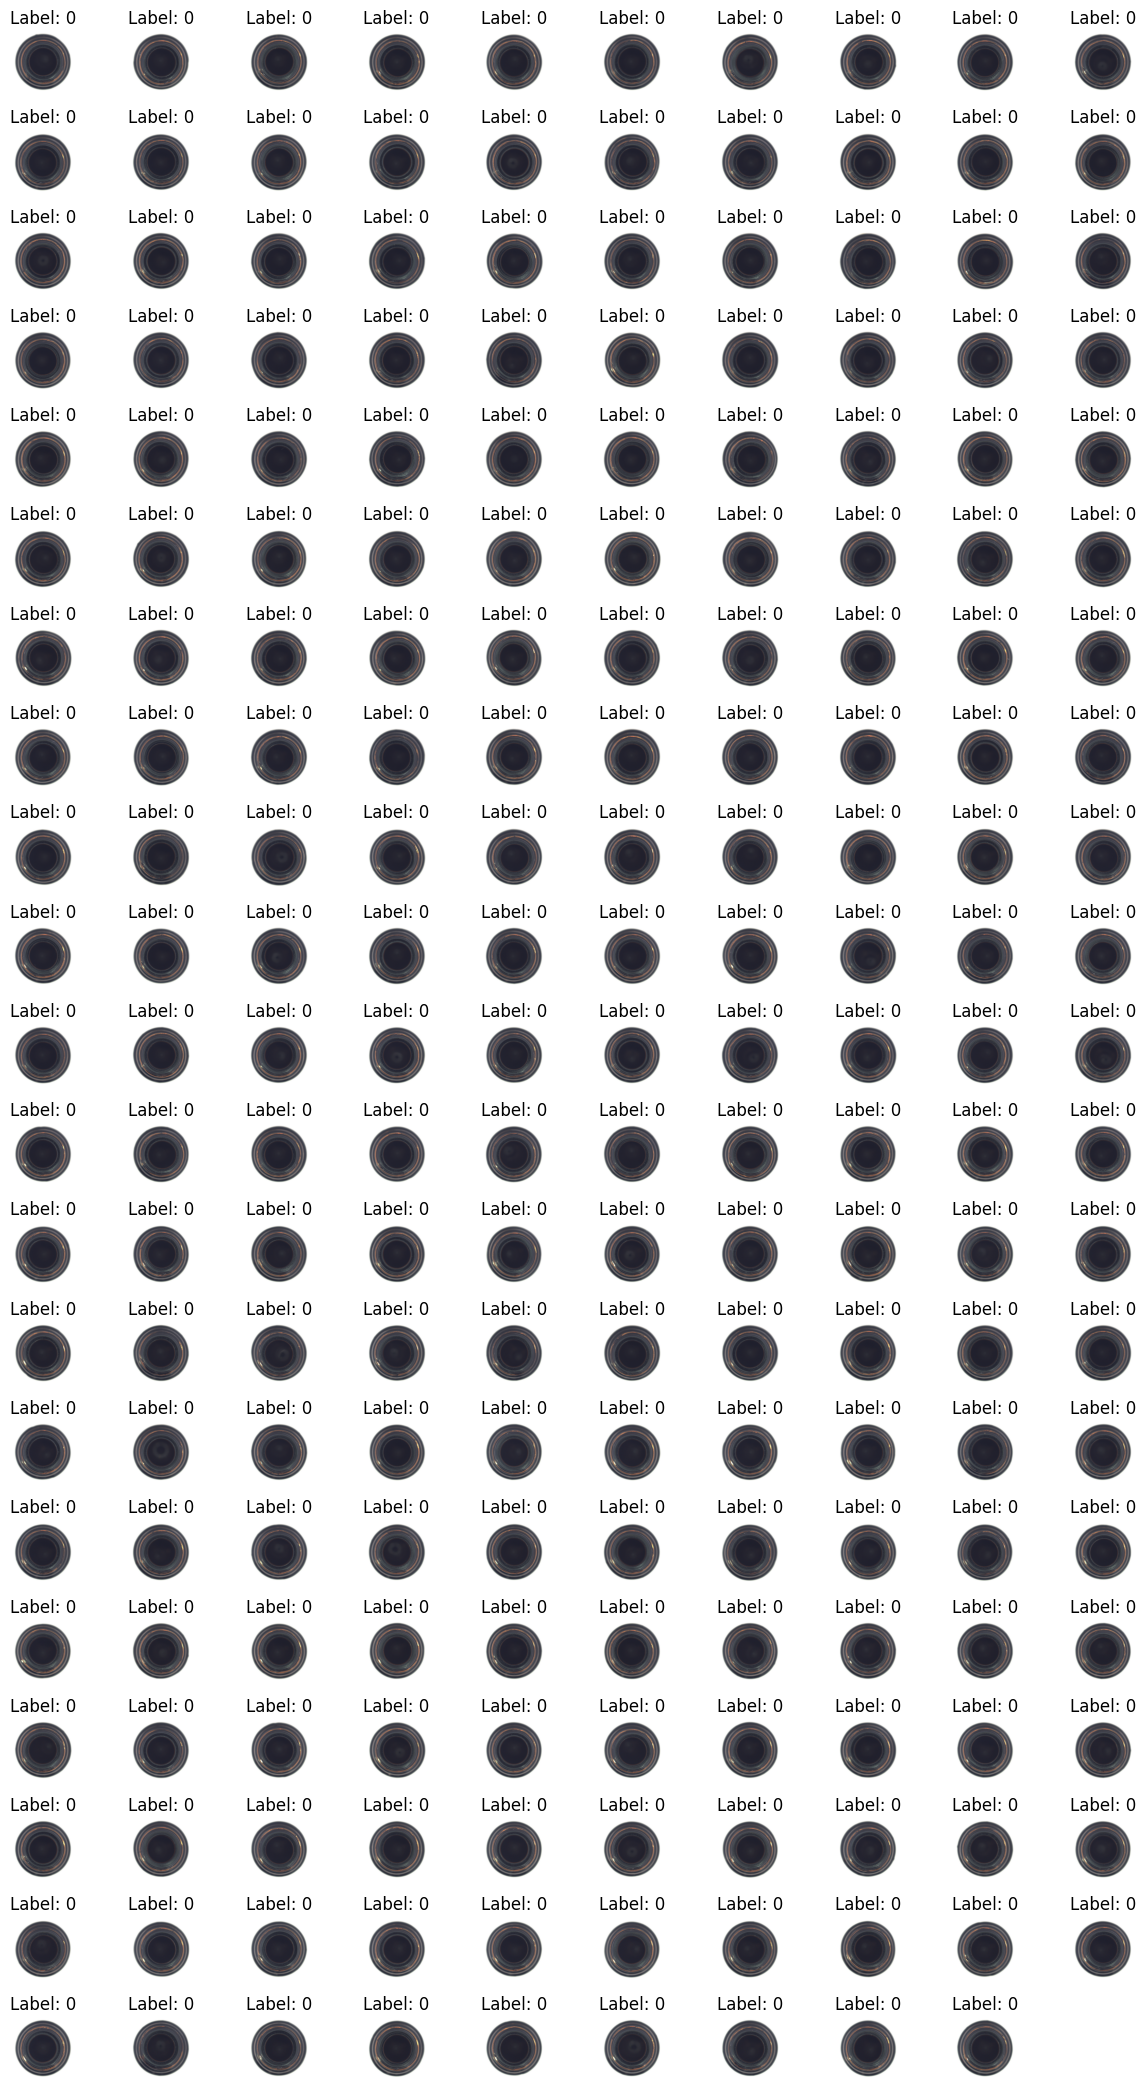

In [83]:
cols = 10
rows = (len(train_dataset) + cols - 1) // cols
plt.figure(figsize=(12,rows))
for i in range(len(train_dataset)):
    image = train_dataset[i]
    label  = 0 
    plt.subplot(rows, cols, i + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(f"Label: {label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

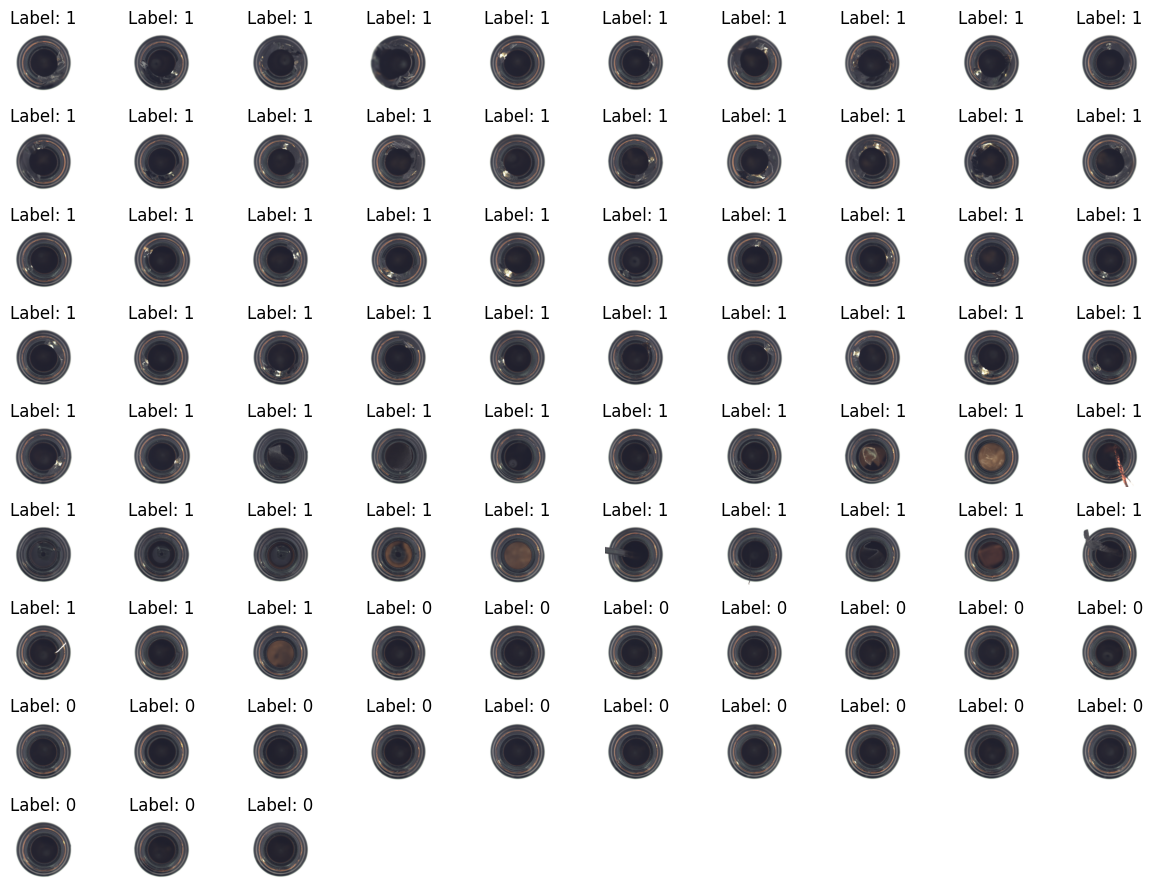

In [84]:
cols = 10
rows = (len(test_dataset) + cols - 1) // cols
plt.figure(figsize=(12,rows))
for i in range(len(test_dataset)):
    image = test_dataset[i][0]
    label = test_dataset[i][1]
    plt.subplot(rows, cols, i + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(f"Label: {label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Model Building Script 

The important idea for anomaly detection is that the autoencoder is trained using the normal good bottle images. It learns to reconstruct the normal appearance. Later, when an anomalous bottle is given to it, the reconstruction error can be used as an anomaly signal. This is the basic reconstruction-based approach relevant to the MVTec setup

In [85]:
from torch import nn, optim

Conv AutoEncoder

In [86]:
import torch
import torch.nn as nn


class ConvAE(nn.Module):

    def __init__(self):
        super().__init__()

        # ENCODER
        # Input: 3 x 256 x 256

        self.encoder = nn.Sequential(

            # 3 x 256 x 256
            # Additional layer for 256x256 input
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 128 x 128
            nn.Conv2d(
                32, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 64 x 64
            nn.Conv2d(
                32, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 64 x 64
            nn.Conv2d(
                32, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 64 x 64
            nn.Conv2d(
                32, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 32 x 32
            nn.Conv2d(
                64, 64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 32 x 32
            nn.Conv2d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 x 16 x 16
            nn.Conv2d(
                128, 64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 16 x 16
            nn.Conv2d(
                64, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 16 x 16
            # Latent representation
            nn.Conv2d(
                32, 128,
                kernel_size=8,
                stride=1,
                padding=0
            )

            # Output: 128 x 1 x 1
        )
        # DECODER

        self.decoder = nn.Sequential(

            # 128 x 1 x 1
            nn.ConvTranspose2d(
                128, 32,
                kernel_size=8,
                stride=1,
                padding=0
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 8 x 8
            nn.ConvTranspose2d(
                32, 64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 8 x 8
            nn.ConvTranspose2d(
                64, 128,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 x 8 x 8
            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 16 x 16
            nn.ConvTranspose2d(
                64, 64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 16 x 16
            nn.ConvTranspose2d(
                64, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 32 x 32
            nn.ConvTranspose2d(
                32, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 32 x 32
            nn.ConvTranspose2d(
                32, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 32 x 32
            nn.ConvTranspose2d(
                32, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 64 x 64
            nn.ConvTranspose2d(
                32, 3,
                kernel_size=4,
                stride=2,
                padding=1
            )

            # Output: 3 x 256 x 256
        )


    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [87]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
x = torch.rand(3, 3).to(device)

Using device: cuda


In [88]:
torch.manual_seed(42)

In [89]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = ConvAE().to(device)

print(model)

ConvAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(32, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): LeakyReLU(negative_slope=0.2, inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): LeakyReLU(negative_slope=0.2, inplace=True)
    (12): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (13): LeakyReLU(negative_slope=0.2, inplace=True)
    (14): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), paddin

In [90]:
x = torch.randn(4, 3, 256, 256).to(device)

with torch.no_grad():
    encoded = model.encoder(x)
    decoded = model.decoder(encoded)

print("Input:", x.shape)
print("Encoded:", encoded.shape)
print("Decoded:", decoded.shape)

Input: torch.Size([4, 3, 256, 256])
Encoded: torch.Size([4, 128, 9, 9])
Decoded: torch.Size([4, 3, 256, 256])


In [91]:
from torch.nn import MSELoss
loss_fn = MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0002
)

In [92]:
EPOCHS=100
train_losses = []
for epoch in range(EPOCHS):

    model.train()
    running_loss = 0.0

    for images in train_loader:
        images = images.to(device)
        reconstructed = model(images)
        loss = loss_fn(reconstructed, images)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(
    f"Epoch [{epoch + 1}/{EPOCHS}], "
    f"Loss: {epoch_loss:.6f}"
)

Epoch [1/100], Loss: 0.314093
Epoch [2/100], Loss: 0.057006
Epoch [3/100], Loss: 0.029627
Epoch [4/100], Loss: 0.021316
Epoch [5/100], Loss: 0.016561
Epoch [6/100], Loss: 0.012251
Epoch [7/100], Loss: 0.009310
Epoch [8/100], Loss: 0.007669
Epoch [9/100], Loss: 0.006772
Epoch [10/100], Loss: 0.006296
Epoch [11/100], Loss: 0.005860
Epoch [12/100], Loss: 0.006683
Epoch [13/100], Loss: 0.005368
Epoch [14/100], Loss: 0.004954
Epoch [15/100], Loss: 0.004884
Epoch [16/100], Loss: 0.004671
Epoch [17/100], Loss: 0.004633
Epoch [18/100], Loss: 0.004279
Epoch [19/100], Loss: 0.004183
Epoch [20/100], Loss: 0.003920
Epoch [21/100], Loss: 0.004241
Epoch [22/100], Loss: 0.003780
Epoch [23/100], Loss: 0.003788
Epoch [24/100], Loss: 0.003573
Epoch [25/100], Loss: 0.003557
Epoch [26/100], Loss: 0.003359
Epoch [27/100], Loss: 0.003551
Epoch [28/100], Loss: 0.003199
Epoch [29/100], Loss: 0.003275
Epoch [30/100], Loss: 0.003104
Epoch [31/100], Loss: 0.003094
Epoch [32/100], Loss: 0.002966
Epoch [33/100], L

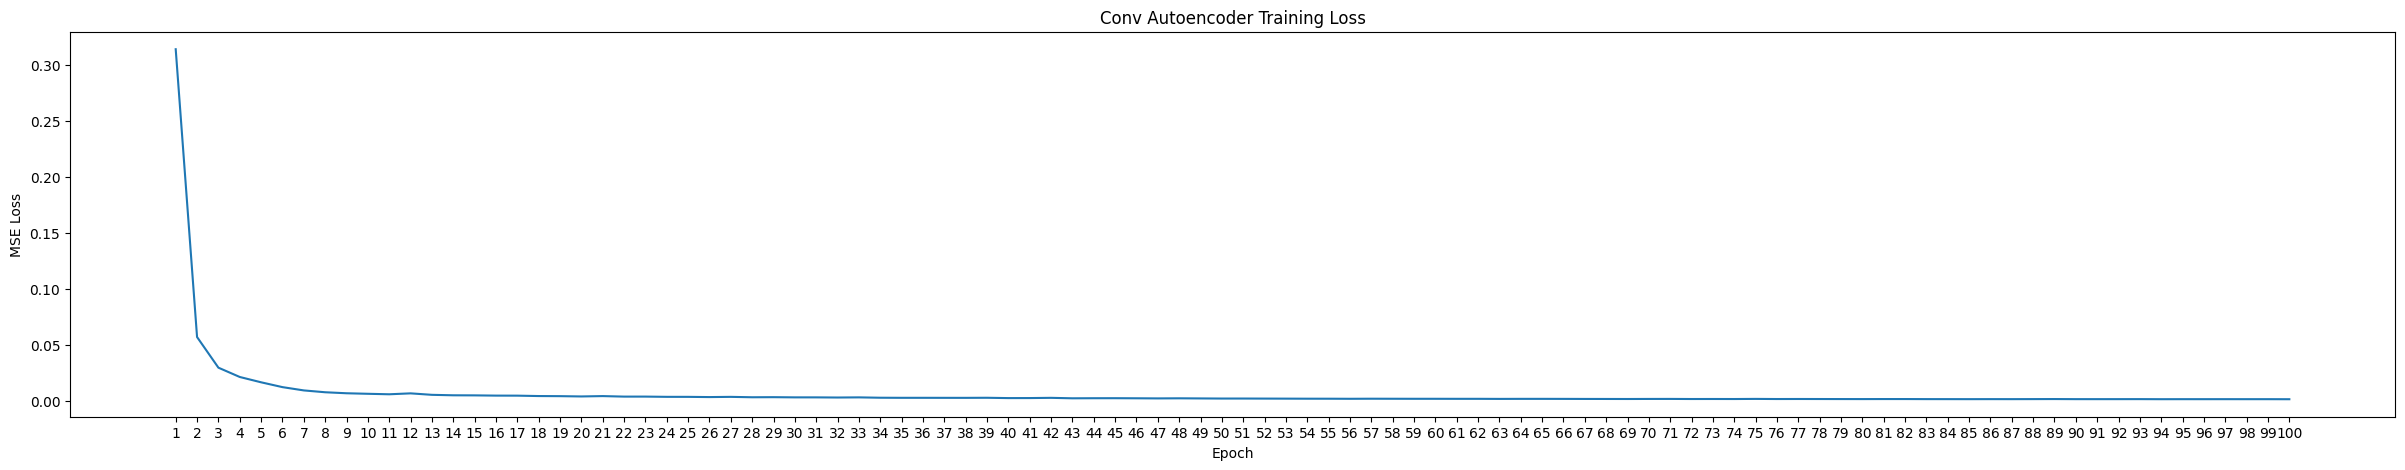

In [120]:
plt.figure(figsize=(30, 5))

plt.plot(range(1, EPOCHS + 1), train_losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Conv Autoencoder Training Loss")
plt.xticks(range(1, EPOCHS + 1))

plt.show()

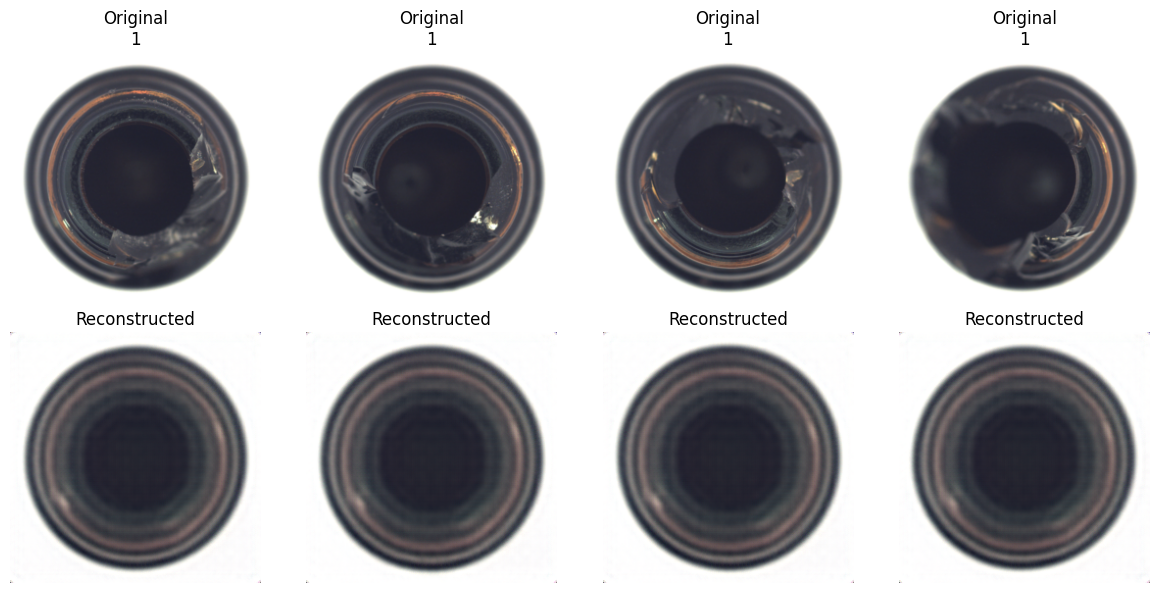

In [99]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    reconstructed = model(images)

fig = plt.figure(figsize=(12, 6))

for i in range(4):

    # Original
    plt.subplot(2, 4, i + 1)
    plt.imshow(
        images[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title(f"Original\n{labels[i].item()}")
    plt.axis("off")

    # Reconstruction
    plt.subplot(2, 4, i + 5)
    plt.imshow(
        reconstructed[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [100]:
model.eval()

all_errors = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        original = images
        reconstructed = model(images)
        errors = torch.mean(
            (images - reconstructed) ** 2,
            dim=(1, 2, 3)
        )

        all_errors.extend(errors.cpu().numpy())
        all_labels.extend(labels.numpy())

In [102]:
print(all_errors)
print(all_errors[0])
print(all_errors[0].shape)
print(len(all_errors))

[np.float32(0.002348011), np.float32(0.0029363595), np.float32(0.0025196797), np.float32(0.00470462), np.float32(0.0040462594), np.float32(0.0019314438), np.float32(0.0031177793), np.float32(0.0023466344), np.float32(0.0032888378), np.float32(0.0018508969), np.float32(0.0024418035), np.float32(0.0018270267), np.float32(0.0028207256), np.float32(0.0026038345), np.float32(0.00358214), np.float32(0.0026489669), np.float32(0.0033256705), np.float32(0.0040678103), np.float32(0.003936724), np.float32(0.0025965339), np.float32(0.0015924223), np.float32(0.0022609131), np.float32(0.003158844), np.float32(0.0035843186), np.float32(0.005712527), np.float32(0.0014214665), np.float32(0.0024329978), np.float32(0.001936239), np.float32(0.0018926108), np.float32(0.0020103147), np.float32(0.0031445832), np.float32(0.0022979237), np.float32(0.003951206), np.float32(0.0019363321), np.float32(0.0023470386), np.float32(0.0017907971), np.float32(0.0018216114), np.float32(0.0038086246), np.float32(0.00581025

In [103]:
threshold = 0.0020
predicted_labels = [
    1 if error > threshold else 0
    for error in all_errors
]

In [104]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(
    all_labels,
    predicted_labels
)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels , predicted_labels))

print("\nClassification Report:")
print(classification_report(all_labels, predicted_labels))

Accuracy: 0.8072289156626506

Confusion Matrix:
[[20  0]
 [16 47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      1.00      0.71        20
           1       1.00      0.75      0.85        63

    accuracy                           0.81        83
   macro avg       0.78      0.87      0.78        83
weighted avg       0.89      0.81      0.82        83



## Finding the Optimal Threshold
Instead of manually guessing, we use data-driven methods:
1. **Training set statistics** — mean + k*std of normal reconstruction errors
2. **ROC / Youden's J** — maximizes balanced accuracy
3. **Precision-Recall / F1** — maximizes F1 score

Maximum image-level reconstruction MSE

In [105]:
import numpy as np
train_errors = []

model.eval()
error = 0
with torch.no_grad():
    for images in train_loader:
        images = images.to(device)
        original = images
        reconstructed = model(images)
        batch_error =  torch.mean((original - reconstructed) ** 2,dim=(1,2,3))
        error = max(error,batch_error.max().item())
print("Max Error Threshold value",error)

Max Error Threshold value 0.0022164396941661835


Maximum PIXEL-level reconstruction MSE

In [106]:
model.eval()

max_pixel_error = 0.0

with torch.no_grad():

    for images in train_loader:

        images = images.to(device)
        reconstructed = model(images)
        original = images
        pixel_error = (original - reconstructed) ** 2
        batch_max_error = pixel_error.max().item()
        max_pixel_error = max(max_pixel_error, batch_max_error)

print("Maximum Pixel-Level Error Threshold:", max_pixel_error)

Maximum Pixel-Level Error Threshold: 0.44415292143821716


K-Sigma Threshold

In [107]:
import numpy as np
train_errors = []

model.eval()
with torch.no_grad():
    for images in train_loader:
        images = images.to(device)
        original = images
        reconstructed = model(images)
        error = torch.mean((original - reconstructed) ** 2, dim=(1,2,3))
        train_errors.extend(error.cpu().numpy())

mean_err = np.mean(train_errors)
std_err = np.std(train_errors)

threshold_2std = mean_err + 2 * std_err
threshold_3std = mean_err + 3 * std_err

print(f"Training error stats:")
print(f"  Mean: {mean_err:.6f}")
print(f"  Std:  {std_err:.6f}")
print(f"  Threshold (mean + 2*std): {threshold_2std:.6f}")
print(f"  Threshold (mean + 3*std): {threshold_3std:.6f}")

Training error stats:
  Mean: 0.001463
  Std:  0.000242
  Threshold (mean + 2*std): 0.001947
  Threshold (mean + 3*std): 0.002189


p-Quantile Threshold

In [108]:
model.eval()

all_pixel_errors = []

with torch.no_grad():
    for images in train_loader:
        images = images.to(device)
        original = images
        reconstructed = model(images)
        pixel_error = (original - reconstructed) ** 2
        all_pixel_errors.append(
            pixel_error.cpu().numpy().reshape(-1)
        )

all_pixel_errors = np.concatenate(all_pixel_errors)
p = 0.99
quantile_threshold = np.quantile(
    all_pixel_errors,
    p
)

print("p-Quantile Threshold:", quantile_threshold)

p-Quantile Threshold: 0.017951174


THESE USES TEST DATA LABELS 

In [109]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

all_errors_np = np.array(all_errors)
all_labels_np = np.array(all_labels)

# Method 2: ROC Curve + Youden's J statistic
fpr, tpr, roc_thresholds = roc_curve(all_labels_np, all_errors_np)
roc_auc = auc(fpr, tpr)

j_scores = tpr - fpr  
best_roc_idx = np.argmax(j_scores)
threshold_youden = roc_thresholds[best_roc_idx]

print(f"Method 2 - ROC / Youden's J:")
print(f"  AUC-ROC: {roc_auc:.4f}")
print(f"  Optimal threshold: {threshold_youden:.6f}")
print(f"  At this threshold -> TPR: {tpr[best_roc_idx]:.3f}, FPR: {fpr[best_roc_idx]:.3f}")

precision, recall, pr_thresholds = precision_recall_curve(all_labels_np, all_errors_np)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_pr_idx = np.argmax(f1_scores)
threshold_f1 = pr_thresholds[best_pr_idx]

print(f"\nMethod 3 - Precision-Recall / Best F1:")
print(f"  Optimal threshold: {threshold_f1:.6f}")
print(f"  At this threshold -> Precision: {precision[best_pr_idx]:.3f}, Recall: {recall[best_pr_idx]:.3f}, F1: {f1_scores[best_pr_idx]:.3f}")

Method 2 - ROC / Youden's J:
  AUC-ROC: 0.9103
  Optimal threshold: 0.002010
  At this threshold -> TPR: 0.746, FPR: 0.000

Method 3 - Precision-Recall / Best F1:
  Optimal threshold: 0.001791
  At this threshold -> Precision: 0.908, Recall: 0.937, F1: 0.922


In [110]:

thresholds_to_test = {
    "Manual (your current)": 0.0020,
    "Mean + 2*Std (training)": threshold_2std,
    "Mean + 3*Std (training)": threshold_3std,
    "Youden's J (ROC)": threshold_youden,
    "Best F1 (PR curve)": threshold_f1,
}

for name, t in thresholds_to_test.items():
    preds = [1 if e > t else 0 for e in all_errors]
    acc = accuracy_score(all_labels_np, preds)
    cm = confusion_matrix(all_labels_np, preds)
    print(cm)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n--- {name} (threshold = {t:.6f}) ---")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  TP={tp}, FP={fp}, FN={fn}, TN={tn}")
    print(f"  Recall (defect detection): {tp/(tp+fn):.3f}")
    print(f"  Precision: {tp/(tp+fp):.3f}" if (tp+fp) > 0 else "  Precision: N/A")

[[20  0]
 [16 47]]

--- Manual (your current) (threshold = 0.002000) ---
  Accuracy: 0.8072
  TP=47, FP=0, FN=16, TN=20
  Recall (defect detection): 0.746
  Precision: 1.000
[[18  2]
 [16 47]]

--- Mean + 2*Std (training) (threshold = 0.001947) ---
  Accuracy: 0.7831
  TP=47, FP=2, FN=16, TN=18
  Recall (defect detection): 0.746
  Precision: 0.959
[[20  0]
 [17 46]]

--- Mean + 3*Std (training) (threshold = 0.002189) ---
  Accuracy: 0.7952
  TP=46, FP=0, FN=17, TN=20
  Recall (defect detection): 0.730
  Precision: 1.000
[[20  0]
 [17 46]]

--- Youden's J (ROC) (threshold = 0.002010) ---
  Accuracy: 0.7952
  TP=46, FP=0, FN=17, TN=20
  Recall (defect detection): 0.730
  Precision: 1.000
[[14  6]
 [ 5 58]]

--- Best F1 (PR curve) (threshold = 0.001791) ---
  Accuracy: 0.8675
  TP=58, FP=6, FN=5, TN=14
  Recall (defect detection): 0.921
  Precision: 0.906


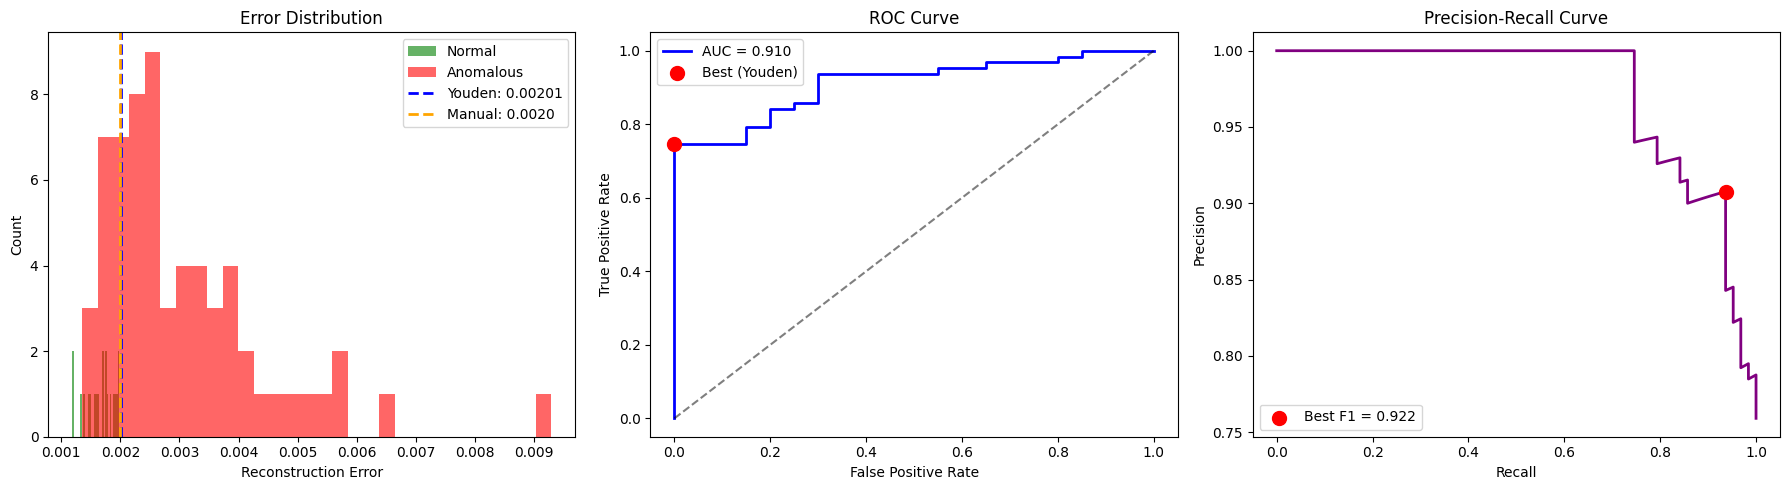

In [116]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


normal_errors = all_errors_np[all_labels_np == 0]
anomalous_errors = all_errors_np[all_labels_np == 1]

axes[0].hist(normal_errors, bins=30, alpha=0.6, label="Normal", color="green")
axes[0].hist(anomalous_errors, bins=30, alpha=0.6, label="Anomalous", color="red")
axes[0].axvline(threshold_youden, color="blue", linestyle="--", linewidth=2, label=f"Youden: {threshold_youden:.5f}")
axes[0].axvline(0.0020, color="orange", linestyle="--", linewidth=2, label=f"Manual: 0.0020")
axes[0].set_xlabel("Reconstruction Error")
axes[0].set_ylabel("Count")
axes[0].set_title("Error Distribution")
axes[0].legend()

# 2. ROC Curve
axes[1].plot(fpr, tpr, color="blue", linewidth=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].scatter(fpr[best_roc_idx], tpr[best_roc_idx], color="red", s=100, zorder=5, label=f"Best (Youden)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# 3. Precision-Recall Curve
axes[2].plot(recall, precision, color="purple", linewidth=2)
axes[2].scatter(recall[best_pr_idx], precision[best_pr_idx], color="red", s=100, zorder=5, label=f"Best F1 = {f1_scores[best_pr_idx]:.3f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend()

plt.tight_layout()
plt.show()

In [117]:

best_threshold = threshold_youden 
print(f"Using optimal threshold: {best_threshold:.6f}")

optimal_preds = [1 if e > best_threshold else 0 for e in all_errors]

print(f"\nAccuracy: {accuracy_score(all_labels_np, optimal_preds):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(all_labels_np, optimal_preds))
print(f"\nClassification Report:")
print(classification_report(all_labels_np, optimal_preds, target_names=["Normal", "Anomaly"]))

Using optimal threshold: 0.002010

Accuracy: 0.7952

Confusion Matrix:
[[20  0]
 [17 46]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.54      1.00      0.70        20
     Anomaly       1.00      0.73      0.84        63

    accuracy                           0.80        83
   macro avg       0.77      0.87      0.77        83
weighted avg       0.89      0.80      0.81        83



In [115]:
torch.save(model.state_dict(), "conv_autoencoder2.pth")